#### Goal - show how the piping in coppertop makes it easier to do a PCA on some equities

I'm going to show my workings here - for didactic and requirements reasons


In [18]:
%matplotlib inline

import datetime, polars as pl, matplotlib.pyplot as plt, pandas as pd, os

from coppertop.pipe import *
from coppertop.utils import Missing
import coppertop.dm.core, coppertop.dm.pp, coppertop.dm.polarframe, coppertop.dm.pandaframe, coppertop.dm.fs, coppertop.dm.linalg.core
from coppertop.dm.core import collect, select, to, take, inject, diffRows, withKeys, values, atCol
from coppertop.dm.polarframe import take, aj, rename, drop, takePanel, where
from coppertop.dm import polarframe
from coppertop.dm import linalg
import coppertop.dm.frame.csv
from coppertop.dm.pp import PP, DD
from coppertop.dm import fs

'~/arwen/coppertop-libs/jupyter' >> fs.expandUser >> fs.setCwd;

<br>

#### piped function calls vs nested function calls

Many people seem to find the left to right style of pipeline style easier to read than nesting functions. Compare this:

In [19]:
list(filter(lambda x: x > 2, map(lambda x: x + 1, [1,2,3])))

[3, 4]

with this (where map => collect, filter => select):

In [20]:
[1,2,3] >> collect >> (lambda x: x + 1) >> select >> (lambda x: x > 2)

[3, 4]

or using the convention that a trailing underscore in a function names indicates a deferred function:

In [21]:
@coppertop(style=binary)
def collect_(xs, fn):
    return map(fn, xs)

@coppertop(style=binary)
def select_(xs, fn):
    return filter(fn, xs)

[1,2,3] >> collect_  >> (lambda x: x + 1) >> select_ >> (lambda x: x > 2) >> to >> list

[3, 4]

Just for interest these are the bones equivalents
```
(1,2,3) collect {x + 1} select {x > 2}
(1,2,3) collect_ {x + 1} select_ {x > 2} to <:N**count>

```


<br>

#### PCA

First - on a train journey I downloaded some stocks from Yahoo Finance - https://finance.yahoo.com/quote/MSFT/history?p=MSFT etc




In [22]:
fs >> DD

['FileNotMovedError', 'JJ', 'OCTAL_FORMAT', 'XX', 'XX1', '_', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'basename', 'binary', 'bool', 'context', 'coppertop', 'counter', 'datetime', 'deepDeleteEmptyFolders', 'deepDeleteFiles', 'deepDeleteFilesWithinSubfolders', 'deepFindFiles', 'deepFindFilesWithinSubfolders', 'deepFindNamedSubfolders', 'deepMoveFiles', 'deleteEmptyFolder', 'deleteFile', 'drop', 'ensureFolder', 'ensureFolderWithXX', 'expandUser', 'fitsWithin', 'folderEntries', 'getCwd', 'gid', 'glob', 'hasFiles', 'isFile', 'isFolder', 'isFolderEmpty', 'joinPath', 'macosUnlock', 'makeFn', 'mask2perm', 'modTime', 'moveFile', 'nanoToDT', 'nullary', 'os', 'pathlib', 'perm2mask', 'ppDT', 'pylist', 'replicateFolders', 'scanFiles', 'scanFolders', 'setCwd', 'shutil', 'sig', 'size', 'startsWith', 'stat', 'stats', 'sys', 'ternary', 'txt', 'type', 'typeOf', 'uid', 'unary']


<module 'coppertop.dm.fs' from '/Users/david/arwen/coppertop-libs/src/coppertop/dm/fs.py'>

In [23]:
'./analysis/data' >> fs.scanFiles

['.DS_Store',
 'AMZN.csv',
 'MSFT.csv',
 'us yields.csv',
 'TSLA.csv',
 'GOOG.csv',
 'AAPL.csv']

In [24]:
'./analysis/data/AMZN.csv' >> polarframe.read >> PP;

shape: (6_435, 7)
┌────────────┬───────────┬───────────┬───────────┬───────────┬───────────┬────────────┐
│ Date       ┆ Open      ┆ High      ┆ Low       ┆ Close     ┆ Adj Close ┆ Volume     │
│ ---        ┆ ---       ┆ ---       ┆ ---       ┆ ---       ┆ ---       ┆ ---        │
│ date       ┆ f64       ┆ f64       ┆ f64       ┆ f64       ┆ f64       ┆ i64        │
╞════════════╪═══════════╪═══════════╪═══════════╪═══════════╪═══════════╪════════════╡
│ 1997-05-15 ┆ 0.121875  ┆ 0.125     ┆ 0.096354  ┆ 0.097917  ┆ 0.097917  ┆ 1443120000 │
│ 1997-05-16 ┆ 0.098438  ┆ 0.098958  ┆ 0.085417  ┆ 0.086458  ┆ 0.086458  ┆ 294000000  │
│ 1997-05-19 ┆ 0.088021  ┆ 0.088542  ┆ 0.08125   ┆ 0.085417  ┆ 0.085417  ┆ 122136000  │
│ 1997-05-20 ┆ 0.086458  ┆ 0.0875    ┆ 0.081771  ┆ 0.081771  ┆ 0.081771  ┆ 109344000  │
│ 1997-05-21 ┆ 0.081771  ┆ 0.082292  ┆ 0.06875   ┆ 0.071354  ┆ 0.071354  ┆ 377064000  │
│ …          ┆ …         ┆ …         ┆ …         ┆ …         ┆ …         ┆ …          │
│ 2022-12-01 ┆

or as a pandas dataframe

In [25]:
# './analysis/data/AMZN.csv' >> pandaframe.read >> to >> pd.DataFrame

In [26]:
d1 = datetime.date(2021, 12, 1)
d2 = datetime.date(2022, 11, 30)

AMZN = './analysis/data/AMZN.csv'  \
    >> polarframe.read \
    >> take >> ['Date', 'Close'] \
    >> where >> ((d1 <= pl.col("Date")) & (pl.col("Date") <= d2))
MSFT = './analysis/data/MSFT.csv'  \
    >> polarframe.read \
    >> take >> ['Date', 'Close'] \
    >> where >> ((d1 <= pl.col("Date")) & (pl.col("Date") <= d2))
AAPL = './analysis/data/AAPL.csv'  \
    >> polarframe.read \
    >> take >> ['Date', 'Close'] \
    >> where >> ((d1 <= pl.col("Date")) & (pl.col("Date") <= d2))
TSLA = './analysis/data/TSLA.csv'  \
    >> polarframe.read \
    >> take >> ['Date', 'Close'] \
    >> where >> ((d1 <= pl.col("Date")) & (pl.col("Date") <= d2))
GOOG = './analysis/data/GOOG.csv'  \
    >> polarframe.read \
    >> take >> ['Date', 'Close'] \
    >> where >> ((d1 <= pl.col("Date")) & (pl.col("Date") <= d2))

Let's join them together. I have aj (asof join for dataframes)

OPEN: aj needs to name the columns better - the standard polars ones are not scalable and the api should be the same accross all versions, maybe a kdb like column rename would be better.

OPEN: naming is slightly different for immutable languges - withNames for mutable languages, setNames for immutable - is `MSFT >> setNames >> [_,'MSFT']` good? q had xcols and xcol and I had to look up, `MSFT >> reorder >> ['MSFT']`


In [27]:
aj >> sig

['(polars.dataframe.frame.DataFrame,polars.dataframe.frame.DataFrame,txt,txt)->py <binary>  :   in coppertop.dm.polarframe.aj',
 '(polars.dataframe.frame.DataFrame,polars.dataframe.frame.DataFrame,txt,txt,txt)->py <binary>  :   in coppertop.dm.polarframe.aj']

OPEN: alias polars.internals.dataframe.frame.DataFrame as something clear and short \
let's try this (turns out to be a good guess but don't like the new name `Close_right`)

In [28]:
AMZN >> aj(_,_,'Date', 'Date') >> MSFT >> PP;

shape: (252, 3)
┌────────────┬────────────┬─────────────┐
│ Date       ┆ Close      ┆ Close_right │
│ ---        ┆ ---        ┆ ---         │
│ date       ┆ f64        ┆ f64         │
╞════════════╪════════════╪═════════════╡
│ 2021-12-01 ┆ 172.186005 ┆ 330.079987  │
│ 2021-12-02 ┆ 171.867996 ┆ 329.48999   │
│ 2021-12-03 ┆ 169.489502 ┆ 323.01001   │
│ 2021-12-06 ┆ 171.3685   ┆ 326.190002  │
│ 2021-12-07 ┆ 176.164505 ┆ 334.920013  │
│ …          ┆ …          ┆ …           │
│ 2022-11-23 ┆ 94.129997  ┆ 247.580002  │
│ 2022-11-25 ┆ 93.410004  ┆ 247.490005  │
│ 2022-11-28 ┆ 93.949997  ┆ 241.759995  │
│ 2022-11-29 ┆ 92.419998  ┆ 240.330002  │
│ 2022-11-30 ┆ 96.540001  ┆ 255.139999  │
└────────────┴────────────┴─────────────┘


as I have to know that the new column name will be appended with "\_right" and that if I call it again it throws an error - to me the api just doesn't scale

In [29]:
try:
    AMZN \
        >> aj(_,_,'Date', 'Date') >> MSFT \
        >> aj(_,_,'Date', 'Date') >> AAPL \
        >> PP
except Exception as ex:
    ex >> PP

column with name 'Close_right' already exists

You may want to try:
- renaming the column prior to joining
- using the `suffix` parameter to specify a suffix different to the default one ('_right')


In [30]:
AMZN >> rename(_, 'Close', 'AMZN')  \
    >> aj(_,_,'Date', 'Date') >> MSFT >> rename(_, 'Close', 'MSFT') \
    >> aj(_,_,'Date', 'Date') >> AAPL >> rename(_, 'Close', 'AAPL') \
    >> PP;

shape: (252, 4)
┌────────────┬────────────┬────────────┬────────────┐
│ Date       ┆ AMZN       ┆ MSFT       ┆ AAPL       │
│ ---        ┆ ---        ┆ ---        ┆ ---        │
│ date       ┆ f64        ┆ f64        ┆ f64        │
╞════════════╪════════════╪════════════╪════════════╡
│ 2021-12-01 ┆ 172.186005 ┆ 330.079987 ┆ 164.770004 │
│ 2021-12-02 ┆ 171.867996 ┆ 329.48999  ┆ 163.759995 │
│ 2021-12-03 ┆ 169.489502 ┆ 323.01001  ┆ 161.839996 │
│ 2021-12-06 ┆ 171.3685   ┆ 326.190002 ┆ 165.320007 │
│ 2021-12-07 ┆ 176.164505 ┆ 334.920013 ┆ 171.179993 │
│ …          ┆ …          ┆ …          ┆ …          │
│ 2022-11-23 ┆ 94.129997  ┆ 247.580002 ┆ 151.070007 │
│ 2022-11-25 ┆ 93.410004  ┆ 247.490005 ┆ 148.110001 │
│ 2022-11-28 ┆ 93.949997  ┆ 241.759995 ┆ 144.220001 │
│ 2022-11-29 ┆ 92.419998  ┆ 240.330002 ┆ 141.169998 │
│ 2022-11-30 ┆ 96.540001  ┆ 255.139999 ┆ 148.029999 │
└────────────┴────────────┴────────────┴────────────┘


In [31]:
closesFrame = AMZN >> rename(_, 'Close', 'AMZN') \
    >> aj(_,_,'Date', 'Date') >> MSFT >> rename(_, 'Close', 'MSFT') \
    >> aj(_,_,'Date', 'Date') >> AAPL >> rename(_, 'Close', 'AAPL') \
    >> aj(_,_,'Date', 'Date') >> TSLA >> rename(_, 'Close', 'TSLA') \
    >> aj(_,_,'Date', 'Date') >> GOOG >> rename(_, 'Close', 'GOOG')
closesFrame >> PP;

shape: (252, 6)
┌────────────┬────────────┬────────────┬────────────┬────────────┬────────────┐
│ Date       ┆ AMZN       ┆ MSFT       ┆ AAPL       ┆ TSLA       ┆ GOOG       │
│ ---        ┆ ---        ┆ ---        ┆ ---        ┆ ---        ┆ ---        │
│ date       ┆ f64        ┆ f64        ┆ f64        ┆ f64        ┆ f64        │
╞════════════╪════════════╪════════════╪════════════╪════════════╪════════════╡
│ 2021-12-01 ┆ 172.186005 ┆ 330.079987 ┆ 164.770004 ┆ 365.0      ┆ 141.617996 │
│ 2021-12-02 ┆ 171.867996 ┆ 329.48999  ┆ 163.759995 ┆ 361.533325 ┆ 143.776505 │
│ 2021-12-03 ┆ 169.489502 ┆ 323.01001  ┆ 161.839996 ┆ 338.323334 ┆ 142.520493 │
│ 2021-12-06 ┆ 171.3685   ┆ 326.190002 ┆ 165.320007 ┆ 336.33667  ┆ 143.796494 │
│ 2021-12-07 ┆ 176.164505 ┆ 334.920013 ┆ 171.179993 ┆ 350.583344 ┆ 148.036499 │
│ …          ┆ …          ┆ …          ┆ …          ┆ …          ┆ …          │
│ 2022-11-23 ┆ 94.129997  ┆ 247.580002 ┆ 151.070007 ┆ 183.199997 ┆ 98.82      │
│ 2022-11-25 ┆ 93.410004

We can do better

In [32]:
d1 = datetime.date(2021, 12, 1)
d2 = datetime.date(2022, 11, 30)

allSeries = ['AMZN', 'MSFT', 'AAPL', 'TSLA', 'GOOG'] >> collect >> (lambda name: 
    f'./analysis/data/{name}.csv'
        >> polarframe.read 
        >> take >> ['Date', 'Close']
        >> rename(_, 'Close', name)
        >> where >> ((d1 <= pl.col("Date")) & (pl.col("Date") <= d2))
) 

closesFrame = allSeries >> inject(_, Missing, _) >> (lambda prior, each: 
    each if prior is Missing else prior >> aj(_,_,'Date','Date') >> each
)

closesFrame >> PP;

shape: (252, 6)
┌────────────┬────────────┬────────────┬────────────┬────────────┬────────────┐
│ Date       ┆ AMZN       ┆ MSFT       ┆ AAPL       ┆ TSLA       ┆ GOOG       │
│ ---        ┆ ---        ┆ ---        ┆ ---        ┆ ---        ┆ ---        │
│ date       ┆ f64        ┆ f64        ┆ f64        ┆ f64        ┆ f64        │
╞════════════╪════════════╪════════════╪════════════╪════════════╪════════════╡
│ 2021-12-01 ┆ 172.186005 ┆ 330.079987 ┆ 164.770004 ┆ 365.0      ┆ 141.617996 │
│ 2021-12-02 ┆ 171.867996 ┆ 329.48999  ┆ 163.759995 ┆ 361.533325 ┆ 143.776505 │
│ 2021-12-03 ┆ 169.489502 ┆ 323.01001  ┆ 161.839996 ┆ 338.323334 ┆ 142.520493 │
│ 2021-12-06 ┆ 171.3685   ┆ 326.190002 ┆ 165.320007 ┆ 336.33667  ┆ 143.796494 │
│ 2021-12-07 ┆ 176.164505 ┆ 334.920013 ┆ 171.179993 ┆ 350.583344 ┆ 148.036499 │
│ …          ┆ …          ┆ …          ┆ …          ┆ …          ┆ …          │
│ 2022-11-23 ┆ 94.129997  ┆ 247.580002 ┆ 151.070007 ┆ 183.199997 ┆ 98.82      │
│ 2022-11-25 ┆ 93.410004

<br>

next take diffs and do the SVD (i.e. to generated the PCA loadings, aka eigenvectors, etc)

In [33]:
vs = closesFrame >> drop >> 'Date' >> takePanel >> diffRows>> linalg.core.pca >> withKeys >> ['v','s']
v, s = vs >> values

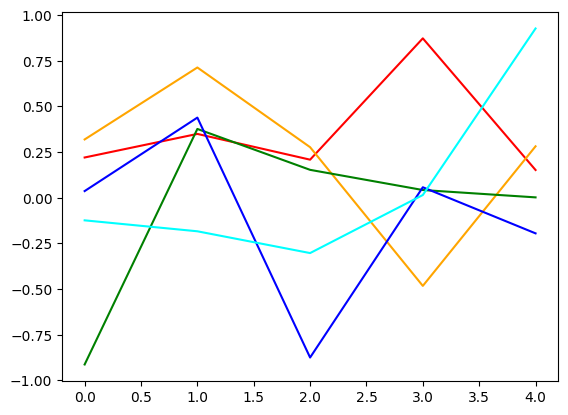

In [34]:
plt.plot(v >> atCol >> 0, 'red')
plt.plot(v >> atCol >> 1, 'orange')
plt.plot(v >> atCol >> 2, 'green')
plt.plot(v >> atCol >> 3, 'blue')
plt.plot(v >> atCol >> 4, 'cyan');